In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps

In [211]:
df = pd.read_csv('https://raw.githubusercontent.com/zalig/cu-datasets/main/advertisment.csv')

In [212]:
print(f"Размер датасета: {df.shape}")
print(df.head())
print(df.info())

Размер датасета: (20000, 7)
   BirthdayYear  Age  Gender  ClientSince   A    B  Purchased
0          2003   21    Male         2023 NaN  NaN        NaN
1          2001   23  Female         2024 NaN  NaN        NaN
2          2002   22    Male         2024 NaN  NaN        NaN
3          2004   20    Male         2023 NaN  1.0        1.0
4          2003   21  Female         2024 NaN  NaN        NaN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   BirthdayYear  20000 non-null  int64  
 1   Age           20000 non-null  int64  
 2   Gender        20000 non-null  object 
 3   ClientSince   20000 non-null  int64  
 4   A             300 non-null    float64
 5   B             500 non-null    float64
 6   Purchased     1327 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 1.1+ MB
None


In [213]:
df['group'] = 'control'
df.loc[df['A'] == 1, 'group'] = 'A'
df.loc[df['B'] == 1, 'group'] = 'B'

df['client_type'] = df['ClientSince'].apply(lambda x: 'давний' if x <= 2023 else 'недавний')
df['age_group'] = df['Age'].apply(lambda x: '<23' if x < 23 else '23+')
df['Purchased'] = df['Purchased'].fillna(0)

# Для конверсии
def conv(data):
  if len(data) == 0:
    return
  return data['Purchased'].mean() * 100

def conv_n(data):
  if len(data) == 0:
    return
  return data['Purchased'].sum()

In [214]:
df.head(5)

,BirthdayYear,Age,Gender,ClientSince,A,B,Purchased,group,client_type,age_group
0,2003,21,Male,2023,NaN,NaN,0.0,control,давний,<23
1,2001,23,Female,2024,NaN,NaN,0.0,control,недавний,23+
2,2002,22,Male,2024,NaN,NaN,0.0,control,недавний,<23
3,2004,20,Male,2023,NaN,1.0,1.0,B,давний,<23
4,2003,21,Female,2024,NaN,NaN,0.0,control,недавний,<23


# Текущая ситуация

In [215]:
print(f'Всего клиентов: {len(df)}')
print(f'Клиентов в группе A: {len(df[df['group'] == 'A'])}')
print(f'Клиентов в группе B: {len(df[df['group'] == 'B'])}')
print(f'Клиентов в контрольной группе: {len(df[df['group'] == 'control'])}')

print('\nКонверсия')
print(f'Среди всех: конверсия {conv(df):.2f}%, количество = {conv_n(df)}')
print(f'Среди группы A: конверсия {conv(df[df['group'] == 'A']):.2f}%, количество = {conv_n(df[df['group'] == 'A'])}')
print(f'Среди группы B: конверсия {conv(df[df['group'] == 'B']):.2f}%, количество = {conv_n(df[df['group'] == 'B'])}')
print(f'Среди контрольной группы: конверсия {conv(df[df['group'] == 'control']):.2f}%, количество = {conv_n(df[df['group'] == 'control'])}')

Всего клиентов: 20000
Клиентов в группе A: 300
Клиентов в группе B: 500
Клиентов в контрольной группе: 19200

Конверсия
Среди всех: конверсия 6.64%, количество = 1327.0
Среди группы A: конверсия 11.00%, количество = 33.0
Среди группы B: конверсия 13.20%, количество = 66.0
Среди контрольной группы: конверсия 6.40%, количество = 1228.0


# Сценарии запуска

In [216]:
N_control = (df['group']=='control').sum()
C = conv(df[df['group'] == 'control']) / 100
P_A = conv(df[df['group'] == 'A']) / 100
P_B = conv(df[df['group'] == 'B']) / 100

add_A = (P_A - C) * N_control
add_B = (P_B - C) * N_control

print(f"Сценарий 1:")
print(f"Доп. покупки: {add_A:.0f}")
print(f"\nСценарий 2:")
print(f"Доп. покупки: {add_B:.0f}")

Сценарий 1:
Доп. покупки: 884

Сценарий 2:
Доп. покупки: 1306


# Тесты значимости

In [217]:
def z_test_prop(g1, g2):
  n1, x1 = len(g1), g1.sum()
  n2, x2 = len(g2), g2.sum()

  p1, p2 = x1/n1, x2/n2
  p_pool = (x1 + x2) / (n1 + n2)
  se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))

  if se == 0:
      return 1.0, (p1 - p2)*100

  z = (p1 - p2) / se
  p_val = 2 * (1 - sps.norm.cdf(abs(z)))

  return p_val, (p1 - p2)*100

In [218]:
alpha_series = 0.05 / 3  # используем поправку Бонферрони для 3 тестов

p_A_ctrl, diff_A = z_test_prop(
  df[df['group']=='A']['Purchased'],
  df[df['group']=='control']['Purchased']
)

p_B_ctrl, diff_B = z_test_prop(
  df[df['group']=='B']['Purchased'],
  df[df['group']=='control']['Purchased']
)

p_A_B, diff_AB = z_test_prop(
  df[df['group']=='A']['Purchased'],
  df[df['group']=='B']['Purchased']
)
print(f"{'A vs control:'}  {p_A_ctrl:.4f}  {diff_A:.2f} п.п.  {'значимо' if p_A_ctrl < alpha_series else 'не значимо'}")
print(f"{'B vs control:'}  {p_B_ctrl:.4f}  {diff_B:.2f} п.п.  {'значимо' if p_B_ctrl < alpha_series else 'не значимо'}")
print(f"{'A vs B:'}        {p_A_B:.4f}  {diff_AB:.2f} п.п.  {'значимо' if p_A_B < alpha_series else 'не значимо'}")

A vs control:  0.0013  4.60 п.п.  значимо
B vs control:  0.0000  6.80 п.п.  значимо
A vs B:        0.3603  -2.20 п.п.  не значимо


# Распределение пола по группам

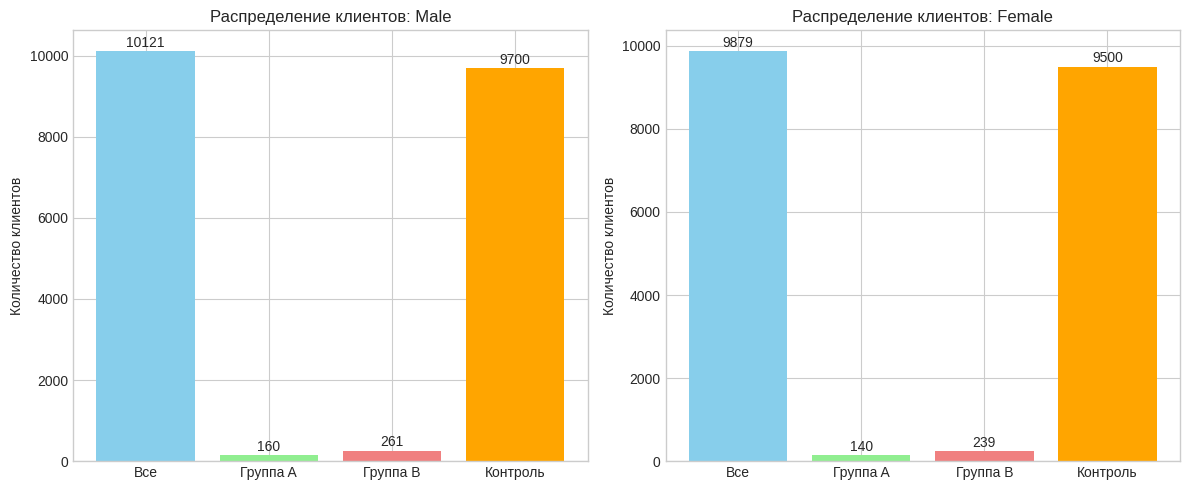

In [219]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
genders = df['Gender'].unique()
for i, gender in enumerate(genders):
  total = (df['Gender']==gender).sum()
  a = ((df['Gender']==gender) & (df['group']=='A')).sum()
  b = ((df['Gender']==gender) & (df['group']=='B')).sum()
  control = ((df['Gender']==gender) & (df['group']=='control')).sum()

  categories = ['Все', 'Группа A', 'Группа B', 'Контроль']
  values = [total, a, b, control]
  axes[i].bar(categories, values, color=['skyblue', 'lightgreen', 'lightcoral', 'orange'])
  axes[i].set_title(f'Распределение клиентов: {gender}')
  axes[i].set_ylabel('Количество клиентов')

  for j, v in enumerate(values):
    axes[i].text(j, v + max(values)*0.01, str(v), ha='center')
plt.tight_layout()
plt.show()

# Распределение пола по возрасту

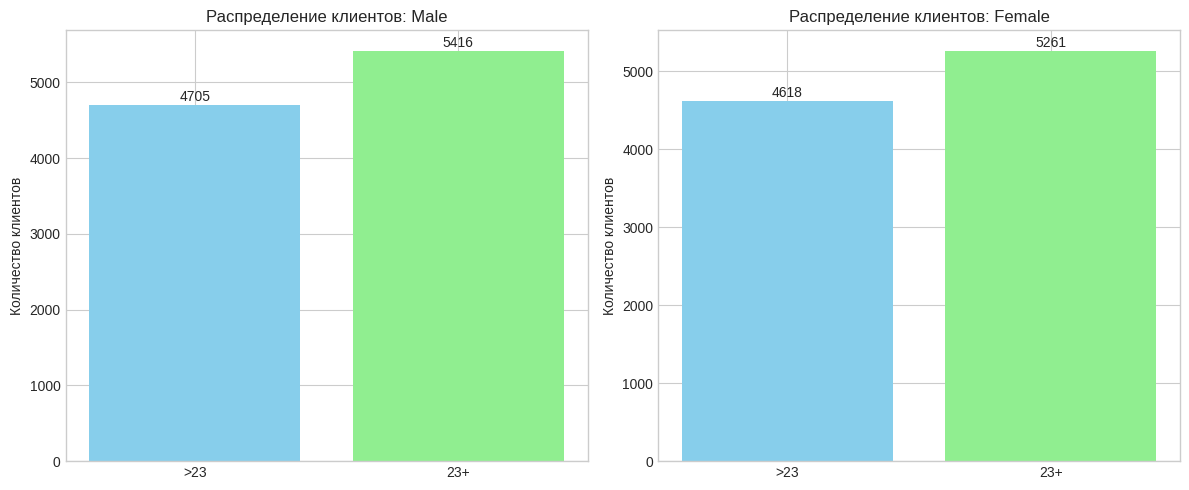

In [220]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
genders = df['Gender'].unique()
for i, gender in enumerate(genders):
  m23 = ((df['Gender']==gender) & (df['age_group']=='<23')).sum()
  b23 = ((df['Gender']==gender) & (df['age_group']=='23+')).sum()

  categories = ['>23', '23+']
  values = [m23, b23]
  axes[i].bar(categories, values, color=['skyblue', 'lightgreen'])
  axes[i].set_title(f'Распределение клиентов: {gender}')
  axes[i].set_ylabel('Количество клиентов')

  for j, v in enumerate(values):
    axes[i].text(j, v + max(values)*0.01, str(v), ha='center')
plt.tight_layout()
plt.show()

# Распределение пола по типу

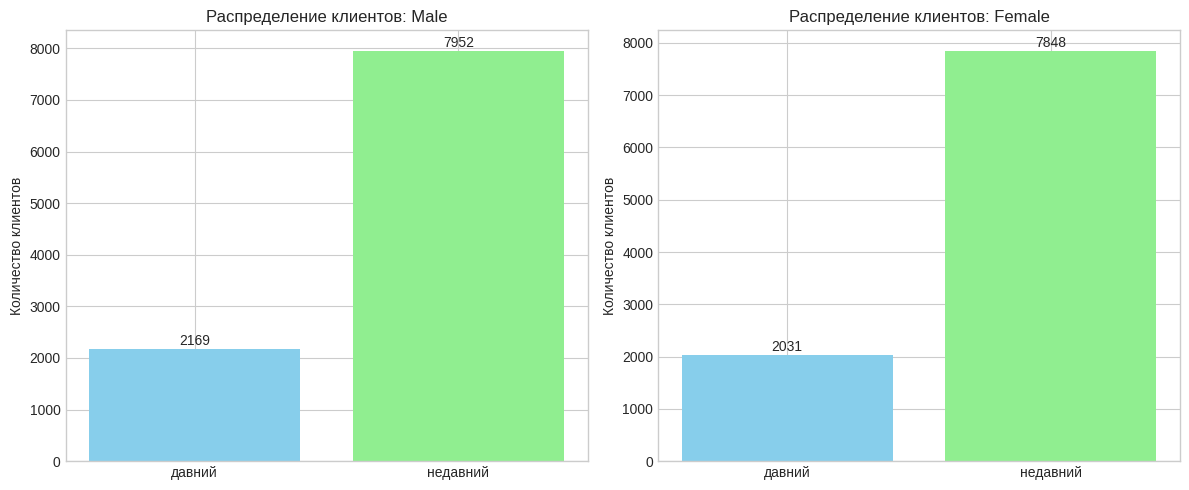

In [221]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
genders = df['Gender'].unique()
for i, gender in enumerate(genders):
  longtime = ((df['Gender']==gender) & (df['client_type']=='давний')).sum()
  shorttime = ((df['Gender']==gender) & (df['client_type']=='недавний')).sum()

  categories = ['давний', 'недавний']
  values = [longtime, shorttime]
  axes[i].bar(categories, values, color=['skyblue', 'lightgreen'])
  axes[i].set_title(f'Распределение клиентов: {gender}')
  axes[i].set_ylabel('Количество клиентов')

  for j, v in enumerate(values):
    axes[i].text(j, v + max(values)*0.01, str(v), ha='center')
plt.tight_layout()
plt.show()

# Проверка теста

In [222]:
print("1. Независимость наблюдений — есть (клиенты рандомизированы)")
print("2. Бинарный исход (купил/не купил) — есть")
print("3. np и n(1-p) >= 10 для обеих групп:")
for name, grp in [('A', 'A'), ('B', 'B'), ('control', 'control')]:
  data = df[df['group']==grp]['Purchased']
  n, p = len(data), data.mean()
  print(f"{name}: n={n}, p={p:.3f}, np={n*p:.1f}, n(1-p)={n*(1-p):.1f} {'есть' if n*p>=10 and n*(1-p)>=10 else 'нет'}")

1. Независимость наблюдений — есть (клиенты рандомизированы)
2. Бинарный исход (купил/не купил) — есть
3. np и n(1-p) >= 10 для обеих групп:
A: n=300, p=0.110, np=33.0, n(1-p)=267.0 есть
B: n=500, p=0.132, np=66.0, n(1-p)=434.0 есть
control: n=19200, p=0.064, np=1228.0, n(1-p)=17972.0 есть


# Экономическая значимость

In [223]:
REVENUE = 3000
COST = 80
MIN_PROFIT = 300_000
N_ALL = 20_000

conv_control = df[df['group']=='control']['Purchased'].mean()

# прибыль = (uplift * N * revenue) - (N * cost)
# uplift = (min_profit + N*cost) / (N*revenue)
required_uplift = (MIN_PROFIT + N_ALL * COST) / (N_ALL * REVENUE)

print("Экономическая значимость")
print(f"Порог прибыли: {MIN_PROFIT} руб.")
print(f"Доход с покупки: {REVENUE} руб.")
print(f"Стоимость рекламы на клиента: {COST} руб.")
print(f"Требуемый uplift в конверсии: +{required_uplift*100:.3f} п.п.")
print()

uplift_A = df[df['group']=='A']['Purchased'].mean() - conv_control
uplift_B = df[df['group']=='B']['Purchased'].mean() - conv_control

print("Фактический uplift:")
print(f"Кампания A: {uplift_A*100:+.3f} п.п.")
print(f"Кампания B: {uplift_B*100:+.3f} п.п.")
print()

def calc_power(n_treat, n_ctrl, p_ctrl, effect_size, alpha=0.05):
  z_alpha = sps.norm.ppf(1 - alpha/2)
  se = np.sqrt(p_ctrl*(1-p_ctrl)/n_ctrl + (p_ctrl+effect_size)*(1-p_ctrl-effect_size)/n_treat)
  if se == 0:
    return 0
  z_beta = abs(effect_size) / se - z_alpha
  return sps.norm.cdf(z_beta)

n_A = len(df[df['group']=='A'])
n_B = len(df[df['group']=='B'])
n_ctrl = len(df[df['group']=='control'])

power_A = calc_power(n_A, n_ctrl, conv_control, required_uplift)
power_B = calc_power(n_B, n_ctrl, conv_control, required_uplift)

print("Мощность теста")
print(f"Кампания A: {power_A*100:.1f}% (N={n_A})")
print(f"Кампания B: {power_B*100:.1f}% (N={n_B})")
print()

print("Вывод:")
if power_A < 0.8 or power_B < 0.8:
  print("Мощность теста < 80% — есть риск не обнаружить реальный эффект.")
  print("Рекомендуется увеличить размер выборки для следующих тестов.")
else:
  print("Мощность достаточна для надёжного обнаружения экономически значимого эффекта.")

Экономическая значимость
Порог прибыли: 300000 руб.
Доход с покупки: 3000 руб.
Стоимость рекламы на клиента: 80 руб.
Требуемый uplift в конверсии: +3.167 п.п.

Фактический uplift:
Кампания A: +4.604 п.п.
Кампания B: +6.804 п.п.

Мощность теста
Кампания A: 45.8% (N=300)
Кампания B: 66.5% (N=500)

Вывод:
Мощность теста < 80% — есть риск не обнаружить реальный эффект.
Рекомендуется увеличить размер выборки для следующих тестов.


# Рекомендации по сбору данных

**Сбор данных в будущем**

1. Рандомизация клиентов по группам до запуска
2. Исключить пересечение кампаний (один клиент — одна группа)
3. Фиксировать время экспозиции рекламы
4. Собирать данные о времени до покупки
5. Увеличить размер выборки для детекции малых эффектов

# Конверсии по типу клиентов

In [224]:
for ct in ['давний', 'недавний']:
  subset = df[df['client_type'] == ct]
  c_control = conv(subset[subset['group'] == 'control'])
  c_A = conv(subset[subset['group'] == 'A'])
  c_B = conv(subset[subset['group'] == 'B'])
  print(f'{ct}: control = {c_control:.2f}%, A = {c_A:.2f}%, B = {c_B:.2f}%')

давний: control = 20.00%, A = 20.00%, B = 20.00%
недавний: control = 2.99%, A = 8.75%, B = 3.00%


# Конверсии по сегментам

In [225]:
for gender in ['Male', 'Female']:
  for ag in ['<23', '23+']:
    for ct in ['давний', 'недавний']:
      mask = (df['Gender'] == gender) & (df['age_group'] == ag) & (df['client_type'] == ct)
      subset = df[mask]
      if len(subset) > 0:
        c_control = conv(subset[subset['group'] == 'control'])
        c_A = conv(subset[subset['group'] == 'A'])
        c_B = conv(subset[subset['group'] == 'B'])
        print(f'{gender}, {ag}, {ct}: control = {c_control:.2f}%, A = {c_A:.2f}%, B = {c_B:.2f}%')

Male, <23, давний: control = 18.96%, A = 14.29%, B = 22.08%
Male, <23, недавний: control = 3.25%, A = 3.39%, B = 2.38%
Male, 23+, давний: control = 20.52%, A = 25.00%, B = 20.22%
Male, 23+, недавний: control = 2.63%, A = 8.45%, B = 1.89%
Female, <23, давний: control = 21.59%, A = 21.43%, B = 19.05%
Female, <23, недавний: control = 3.20%, A = 11.11%, B = 5.00%
Female, 23+, давний: control = 18.95%, A = 18.75%, B = 18.31%
Female, 23+, недавний: control = 2.95%, A = 12.50%, B = 3.08%


# Прогноз прибыли

In [226]:
REV = 3000
COST = 80

def forecast(segment, campaign):
  n = len(segment[segment['group'] == 'control'])
  if n < 20: return None

  conv_ctrl = segment[segment['group']=='control']['Purchased'].mean()
  conv_camp = segment[segment['group']==campaign]['Purchased'].mean()

  uplift = conv_camp - conv_ctrl
  add_purchases = uplift * n
  revenue = add_purchases * REV
  ad_cost = n * COST
  profit = revenue - ad_cost

  p_val, _ = z_test_prop(
      segment[segment['group']==campaign]['Purchased'],
      segment[segment['group']=='control']['Purchased']
  )

  return {
      'add_purchases': add_purchases,
      'revenue': revenue,
      'ad_cost': ad_cost,
      'profit': profit,
      'p_value': p_val,
      'sig': p_val < 0.05
  }

# Кампания A
print('Кампания A')
print(f"{'Сегмент':<35} {'Доп. покупки':>12} {'Доход':>12} {'Расходы':>12} {'Прибыль':>12} {'p-val':>8} {'Значимость'}")
print("-" * 110)

for gender in ['Male', 'Female']:
  for age in ['<23', '23+']:
      for ctype in ['давний', 'недавний']:
          mask = (df['Gender']==gender) & (df['age_group']==age) & (df['client_type']==ctype)
          seg = df[mask]
          res = forecast(seg, 'A')
          if res and abs(res['profit']) > 1:
              name = f"{gender}, {age}, {ctype}"
              sig = "есть" if res['sig'] else "нет"
              print(f"{name:<35} {res['add_purchases']:>12.1f} {res['revenue']:>12.0f} {res['ad_cost']:>12.0f} {res['profit']:>12.0f} {res['p_value']:>8.4f} {sig}")

# Кампания B
print('\nКампания B')
print(f"{'Сегмент':<35} {'Доп. покупки':>12} {'Доход':>12} {'Расходы':>12} {'Прибыль':>12} {'p-val':>8} {'Значимость'}")
print("-" * 110)

for gender in ['Male', 'Female']:
  for age in ['<23', '23+']:
      for ctype in ['давний', 'недавний']:
          mask = (df['Gender']==gender) & (df['age_group']==age) & (df['client_type']==ctype)
          seg = df[mask]
          res = forecast(seg, 'B')
          if res and abs(res['profit']) > 1:
              name = f"{gender}, {age}, {ctype}"
              sig = "есть" if res['sig'] else "нет"
              print(f"{name:<35} {res['add_purchases']:>12.1f} {res['revenue']:>12.0f} {res['ad_cost']:>12.0f} {res['profit']:>12.0f} {res['p_value']:>8.4f} {sig}")

Кампания A
Сегмент                             Доп. покупки        Доход      Расходы      Прибыль    p-val Значимость
--------------------------------------------------------------------------------------------------------------
Male, <23, давний                          -41.4      -124286        70880      -195166   0.6574 нет
Male, <23, недавний                          4.9        14847       290160      -275313   0.9533 нет
Male, 23+, давний                           48.8       146250        86960        59290   0.6596 нет
Male, 23+, недавний                        238.5       715437       328000       387437   0.0029 есть
Female, <23, давний                         -1.4        -4286        70400       -74686   0.9883 нет
Female, <23, недавний                      282.3       847000       285360       561640   0.0013 есть
Female, 23+, давний                         -1.9        -5813        78960       -84773   0.9841 нет
Female, 23+, недавний                      388.2      1164750

# MDE

In [227]:
z_alpha = sps.norm.ppf(1 - 0.05/2)
z_beta = sps.norm.ppf(0.8)
p_base = df[df['group'] == 'control']['Purchased'].mean()

def calc_mde(n_treat, n_ctrl):
  se = np.sqrt(p_base*(1-p_base)/n_treat + p_base*(1-p_base)/n_ctrl)
  return (z_alpha + z_beta) * se

n_A = len(df[df['group'] == 'A'])
n_B = len(df[df['group'] == 'B'])
n_ctrl = len(df[df['group'] == 'control'])

mde_A = calc_mde(n_A, n_ctrl)
mde_B = calc_mde(n_B, n_ctrl)

print(f"Базовая конверсия: {p_base*100:.2f}%")
print(f"Кампания A: MDE = {mde_A*100:.2f} п.п. | В деньгах: {mde_A * 20000 * REV:.0f} руб.")
print(f"Кампания B: MDE = {mde_B*100:.2f} п.п. | В деньгах: {mde_B * 20000 * REV:.0f} руб.")
print()

Базовая конверсия: 6.40%
Кампания A: MDE = 3.99 п.п. | В деньгах: 2393081 руб.
Кампания B: MDE = 3.11 п.п. | В деньгах: 1863154 руб.



# Итговая рекомендация

In [228]:
p_A_all, diff_A = z_test_prop(df[df['group']=='A']['Purchased'], df[df['group']=='control']['Purchased'])
p_B_all, diff_B = z_test_prop(df[df['group']=='B']['Purchased'], df[df['group']=='control']['Purchased'])

profit_total_A = diff_A/100 * n_ctrl * REV - n_ctrl * COST
profit_total_B = diff_B/100 * n_ctrl * REV - n_ctrl * COST

print(f"Общий прогноз прибыли на контрольную группу")
print(f"Кампания A: {profit_total_A:.0f} руб. (p={p_A_all:.4f})")
print(f"Кампания B: {profit_total_B:.0f} руб. (p={p_B_all:.4f})")
print(f"Порог экономической значимости: 300 000 руб.")
print(f"Уровень значимости (Бонферрони): {alpha_series:.4f}\n")

if profit_total_A > profit_total_B and profit_total_A >= 300000 and p_A_all < alpha_series:
    print("Кампания A")
elif profit_total_B > profit_total_A and profit_total_B >= 300000 and p_B_all < alpha_series:
    print("Кампания B")
else:
    print("Ни одна кампания не проходит по статистической и экономической значимости")

Общий прогноз прибыли на контрольную группу
Кампания A: 1116000 руб. (p=0.0013)
Кампания B: 2383200 руб. (p=0.0000)
Порог экономической значимости: 300 000 руб.
Уровень значимости (Бонферрони): 0.0167

Кампания B
